# Fidelidad ts-MULE: solo segmentos con relevancia positiva

Esta versi?n eval?a `deletion` e `insertion` usando ?nicamente segmentos con relevancia positiva para la clase predicha.

- Si el modelo predice clase 1, se usan segmentos con relevancia positiva sobre la probabilidad de clase 1.
- Si el modelo predice clase 0, se invierte el signo y se usan segmentos que reducen la probabilidad de clase 1, porque sostienen la predicci?n de clase 0.

La curva ya no llega necesariamente a la se?al completamente degradada/original: solo modifica los segmentos positivos.

In [3]:
from pathlib import Path
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso

PROJECT_ROOT = Path.cwd()

sys.path.insert(0, str(PROJECT_ROOT / 'METHODS' / 'ts-mule'))
warnings.filterwarnings('ignore', category=RuntimeWarning)

from keras.models import load_model
from tsmule.xai.lime import LimeTS
from tsmule.sampling import replace as replacement

print('Proyecto:', PROJECT_ROOT)

Proyecto: /home/ignacio/Proyectos/Proyecto-XAI-2026-main


## 1. Cargar modelo y muestra

In [4]:
with open(PROJECT_ROOT / 'DATA' / 'xtest_new.pickle', 'rb') as file:
    X_test = np.asarray(pickle.load(file), dtype=float)

model = load_model(PROJECT_ROOT / 'MODELS' / 'transfer_learned_tsunami_classifier.keras')

SAMPLE_INDEX = 1
N_RUNS = 20
N_SAMPLES = 100
PARTITIONS = 5
WIN_LENGTH = 4
ALPHA = 1e-4
SEGMENTATION_METHOD = 'slopes-sorted'
REPLACE_METHOD = 'zeros'
CLASS_THRESHOLD = 0.5
RANDOM_SEED = 42

x = np.asarray(X_test[SAMPLE_INDEX], dtype=float)
feature_names = [f'Boya {i + 1}' for i in range(x.shape[1])]
print('Shape:', x.shape)

I0000 00:00:1782280609.784729   66746 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 2205 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 2080, pci bus id: 0000:01:00.0, compute capability: 7.5


Shape: (241, 6)


In [5]:
def predict_proba(x_input):
    x_input = np.asarray(x_input)
    if x_input.ndim == 2:
        x_input = x_input[np.newaxis, ...]
    prediction = model([x_input], training=False)
    return np.asarray(prediction).reshape(-1)


def positive_segment_ranking(relevance, segment_mask, target_sign=1):
    labels = np.unique(segment_mask)
    signed = np.array([
        target_sign * np.mean(relevance[segment_mask == label])
        for label in labels
    ])
    keep = np.where(signed > 0)[0]
    order = keep[np.argsort(signed[keep])[::-1]]
    return labels[order], signed[order]


def deletion_insertion_positive_only(x, relevance, segment_mask, predict_fn, replace_method='zeros', target_sign=1):
    ordered_labels, importance = positive_segment_ranking(relevance, segment_mask, target_sign)
    baseline = getattr(replacement, replace_method)(x, segment_mask)

    if len(ordered_labels) == 0:
        p_original = float(predict_fn(x)[0])
        p_baseline = float(predict_fn(baseline)[0])
        return {
            'fractions': np.array([0.0]),
            'deletion': np.array([p_original]),
            'insertion': np.array([p_baseline]),
            'deletion_auc': np.nan,
            'insertion_auc': np.nan,
            'gap_auc': np.nan,
            'ordered_labels': ordered_labels,
            'importance': importance,
            'n_positive_segments': 0,
            'original_prediction': p_original,
            'baseline_prediction': p_baseline,
        }

    deleted = x.copy()
    inserted = baseline.copy()
    deletion_batch = [deleted.copy()]
    insertion_batch = [inserted.copy()]

    for label in ordered_labels:
        mask = segment_mask == label
        deleted[mask] = baseline[mask]
        inserted[mask] = x[mask]
        deletion_batch.append(deleted.copy())
        insertion_batch.append(inserted.copy())

    fractions = np.arange(len(ordered_labels) + 1) / len(ordered_labels)
    deletion = predict_fn(np.asarray(deletion_batch))
    insertion = predict_fn(np.asarray(insertion_batch))
    deletion_auc = float(np.trapezoid(deletion, fractions))
    insertion_auc = float(np.trapezoid(insertion, fractions))

    assert np.allclose(deletion_batch[0], x)
    assert np.allclose(insertion_batch[0], baseline)

    return {
        'fractions': fractions,
        'deletion': deletion,
        'insertion': insertion,
        'deletion_auc': deletion_auc,
        'insertion_auc': insertion_auc,
        'gap_auc': insertion_auc - deletion_auc,
        'ordered_labels': ordered_labels,
        'importance': importance,
        'n_positive_segments': int(len(ordered_labels)),
        'original_prediction': float(deletion[0]),
        'baseline_prediction': float(insertion[0]),
    }

## 2. Explicaci?n local ts-MULE

In [6]:
np.random.seed(RANDOM_SEED)
relevances, local_r2 = [], []

for run in range(N_RUNS):
    explainer = LimeTS(
        n_samples=N_SAMPLES,
        partitions=PARTITIONS,
        win_length=WIN_LENGTH,
        kernel=Lasso(alpha=ALPHA),
        replace_method=REPLACE_METHOD,
    )
    relevance = explainer.explain(
        x,
        predict_proba,
        segmentation_method=SEGMENTATION_METHOD,
    )
    relevances.append(relevance)
    local_r2.append(explainer.score)

relevance_mean = np.mean(relevances, axis=0)
segments = explainer._segmenter.segment(x, segmentation_method=SEGMENTATION_METHOD)
local_r2 = np.asarray(local_r2)

original_prediction = float(predict_proba(x)[0])
predicted_class = int(original_prediction >= CLASS_THRESHOLD)
target_sign = 1 if predicted_class == 1 else -1

pd.Series({
    'predicci?n original': original_prediction,
    'clase predicha': predicted_class,
    'R? local medio': local_r2.mean(),
    'R? local std': local_r2.std(ddof=1),
}, name='valor').to_frame()

2026-06-24 01:57:10.265703: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92300


,valor
predicci?n original,1.000000
clase predicha,1.000000
R? local medio,-0.727686
R? local std,0.710496


## 3. Deletion/Insertion solo positivo

In [7]:
fidelity = deletion_insertion_positive_only(
    x, relevance_mean, segments, predict_proba, REPLACE_METHOD, target_sign=target_sign
)

pd.Series({
    'segmentos positivos': fidelity['n_positive_segments'],
    'Deletion AUC positivo ?': fidelity['deletion_auc'],
    'Insertion AUC positivo ?': fidelity['insertion_auc'],
    'Gap insertion - deletion ?': fidelity['gap_auc'],
    'Predicci?n original': fidelity['original_prediction'],
    'Predicci?n baseline': fidelity['baseline_prediction'],
}, name='valor').to_frame()

,valor
segmentos positivos,19.000000
Deletion AUC positivo ?,0.578933
Insertion AUC positivo ?,0.954624
Gap insertion - deletion ?,0.375691
Predicci?n original,1.000000
Predicci?n baseline,0.008418


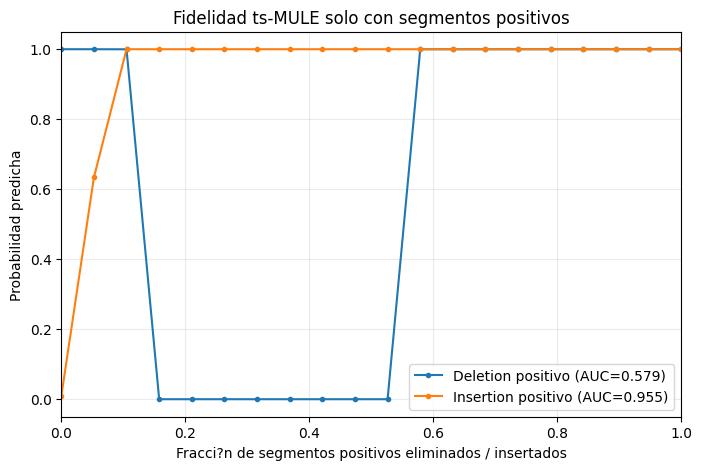

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(fidelity['fractions'], fidelity['deletion'], marker='o', markersize=3,
        label=f"Deletion positivo (AUC={fidelity['deletion_auc']:.3f})")
ax.plot(fidelity['fractions'], fidelity['insertion'], marker='o', markersize=3,
        label=f"Insertion positivo (AUC={fidelity['insertion_auc']:.3f})")
ax.set(
    xlabel='Fracci?n de segmentos positivos eliminados / insertados',
    ylabel='Probabilidad predicha',
    title='Fidelidad ts-MULE solo con segmentos positivos',
    xlim=(0, 1),
)
ax.grid(alpha=.25)
ax.legend()
plt.show()

## 4. Segmentos positivos usados

In [9]:
rows = []
for rank, (label, importance) in enumerate(zip(fidelity['ordered_labels'], fidelity['importance']), start=1):
    positions = np.argwhere(segments == label)
    time_idx = positions[:, 0]
    feature_idx = int(positions[0, 1])
    rows.append({
        'rank': rank,
        'segmento': int(label),
        'feature': feature_names[feature_idx],
        'inicio': int(time_idx.min()),
        'fin': int(time_idx.max()),
        'relevancia positiva clase predicha': float(importance),
        'relevancia firmada original': float(np.mean(relevance_mean[segments == label])),
    })

positive_segment_table = pd.DataFrame(rows)
positive_segment_table.head(20)

,rank,segmento,feature,inicio,fin,relevancia positiva clase predicha,relevancia firmada original
0,1,14,Boya 3,0,36,0.129486,0.129486
1,2,5,Boya 1,106,240,0.120270,0.120270
2,3,35,Boya 6,0,22,0.114087,0.114087
3,4,23,Boya 4,63,77,0.062386,0.062386
4,5,11,Boya 2,113,233,0.059706,0.059706
5,6,0,Boya 1,0,62,0.057065,0.057065
6,7,4,Boya 1,96,105,0.048711,0.048711
7,8,15,Boya 3,37,37,0.040415,0.040415
8,9,3,Boya 1,88,95,0.035968,0.035968
9,10,32,Boya 5,69,112,0.032687,0.032687


## 5. Zonas modificadas y efecto sobre la categorizaci?n

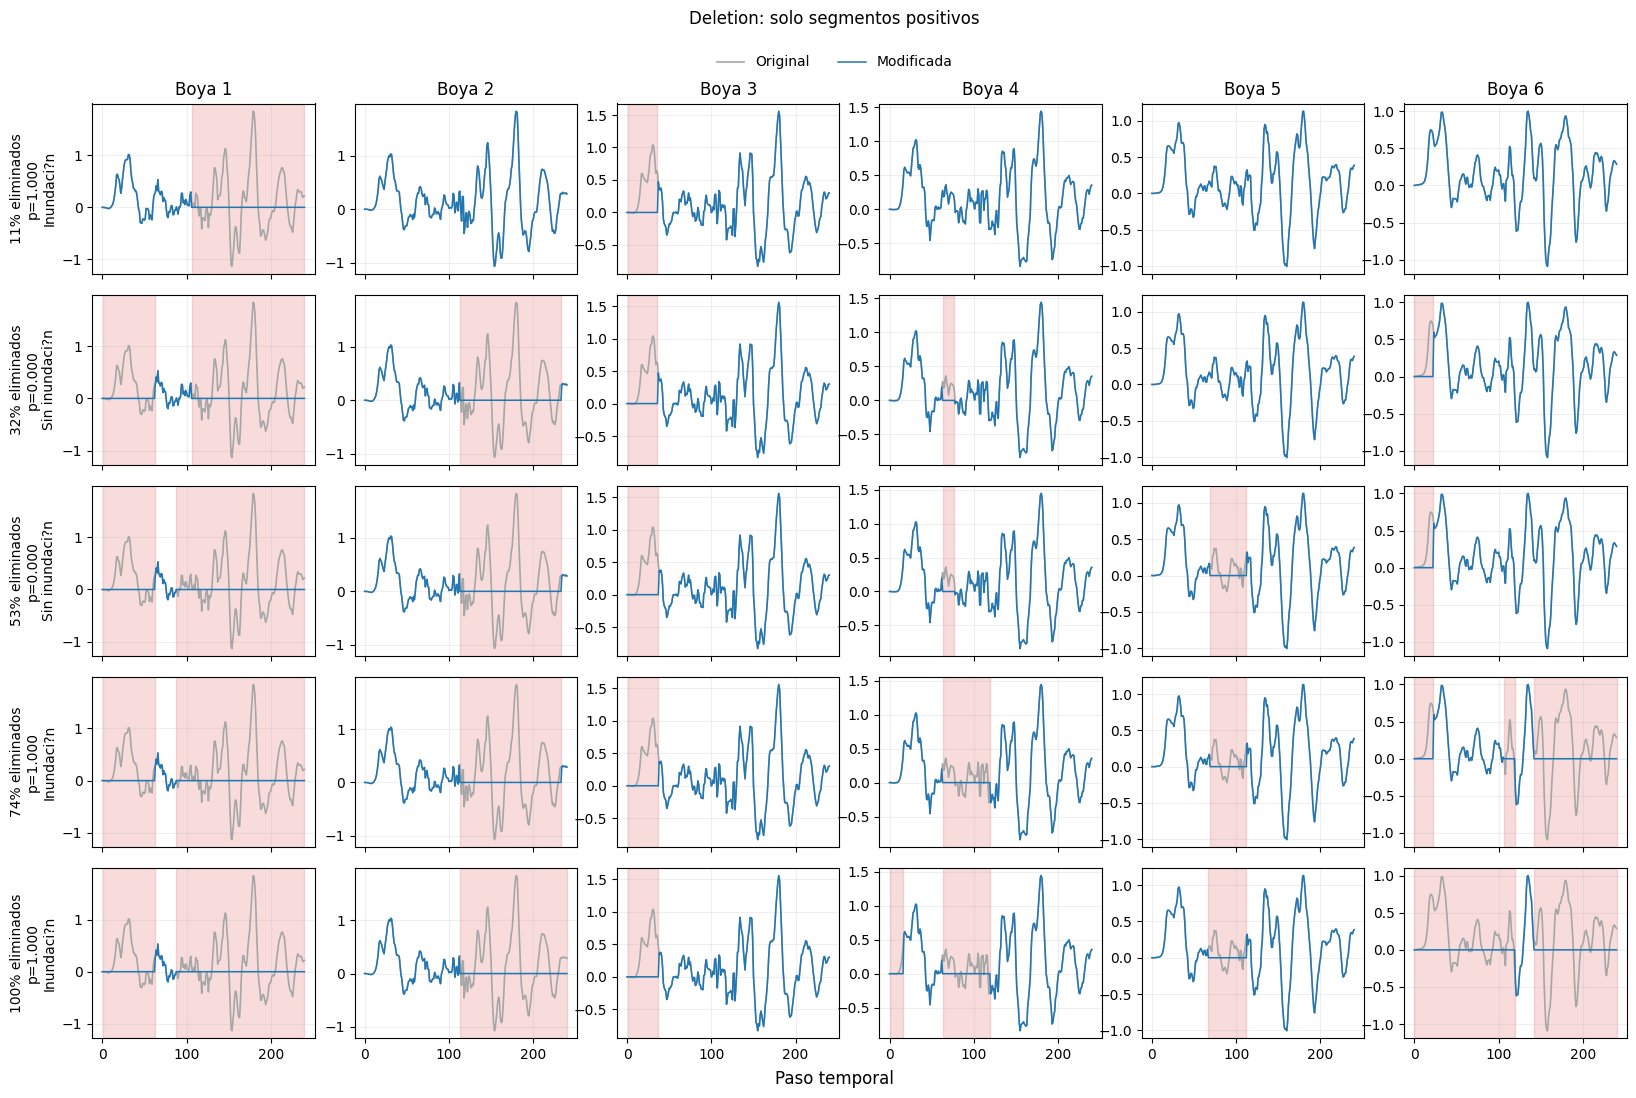

,fracci?n positivos,probabilidad,categor?a
0,0.105263,9.997824e-01,Inundaci?n
1,0.315789,4.232931e-21,Sin inundaci?n
2,0.526316,4.818505e-23,Sin inundaci?n
3,0.736842,1.000000e+00,Inundaci?n
4,1.000000,1.000000e+00,Inundaci?n


In [10]:
CLASS_NAMES = ('Sin inundaci?n', 'Inundaci?n')
CHECKPOINTS = (0.10, 0.30, 0.50, 0.75, 1.00)


def predicted_class_name(probability):
    return CLASS_NAMES[int(probability >= CLASS_THRESHOLD)]


def build_positive_steps(mode):
    baseline = getattr(replacement, REPLACE_METHOD)(x, segments)
    current = x.copy() if mode == 'deletion' else baseline.copy()
    steps = [current.copy()]

    for label in fidelity['ordered_labels']:
        mask = segments == label
        current[mask] = baseline[mask] if mode == 'deletion' else x[mask]
        steps.append(current.copy())

    return np.asarray(steps)


def plot_changed_zones(mode):
    steps = build_positive_steps(mode)
    probabilities = predict_proba(steps)
    n = max(len(fidelity['ordered_labels']), 1)
    indices = sorted(set(int(round(p * n)) for p in CHECKPOINTS))
    indices = [min(i, len(steps) - 1) for i in indices]
    color = 'tab:blue' if mode == 'deletion' else 'tab:orange'
    action = 'eliminados' if mode == 'deletion' else 'insertados'

    fig, axes = plt.subplots(len(indices), x.shape[1], figsize=(3.3 * x.shape[1], 2.2 * len(indices)), sharex=True, squeeze=False)
    for row, step_idx in enumerate(indices):
        modified = steps[step_idx]
        changed = ~np.isclose(modified, x)
        probability = probabilities[step_idx]
        for feature, ax in enumerate(axes[row]):
            ax.plot(x[:, feature], color='0.65', linewidth=1.2, label='Original')
            ax.plot(modified[:, feature], color=color, linewidth=1.1, label='Modificada')
            ax.fill_between(np.arange(x.shape[0]), 0, 1, where=changed[:, feature], color='tab:red', alpha=.16, transform=ax.get_xaxis_transform())
            ax.grid(alpha=.2)
            if row == 0:
                ax.set_title(feature_names[feature])
            if feature == 0:
                ax.set_ylabel(f'{step_idx / n:.0%} {action}\np={probability:.3f}\n{predicted_class_name(probability)}')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 0.965))
    fig.suptitle(f'{mode.capitalize()}: solo segmentos positivos', y=0.995)
    fig.supxlabel('Paso temporal', y=0.015)
    fig.subplots_adjust(top=0.91, bottom=0.06, hspace=0.12, wspace=0.18)
    plt.show()

    return pd.DataFrame({
        'fracci?n positivos': np.asarray(indices) / n,
        'probabilidad': probabilities[indices],
        'categor?a': [predicted_class_name(probabilities[i]) for i in indices],
    })


delete_positive_changes = plot_changed_zones('deletion')
delete_positive_changes

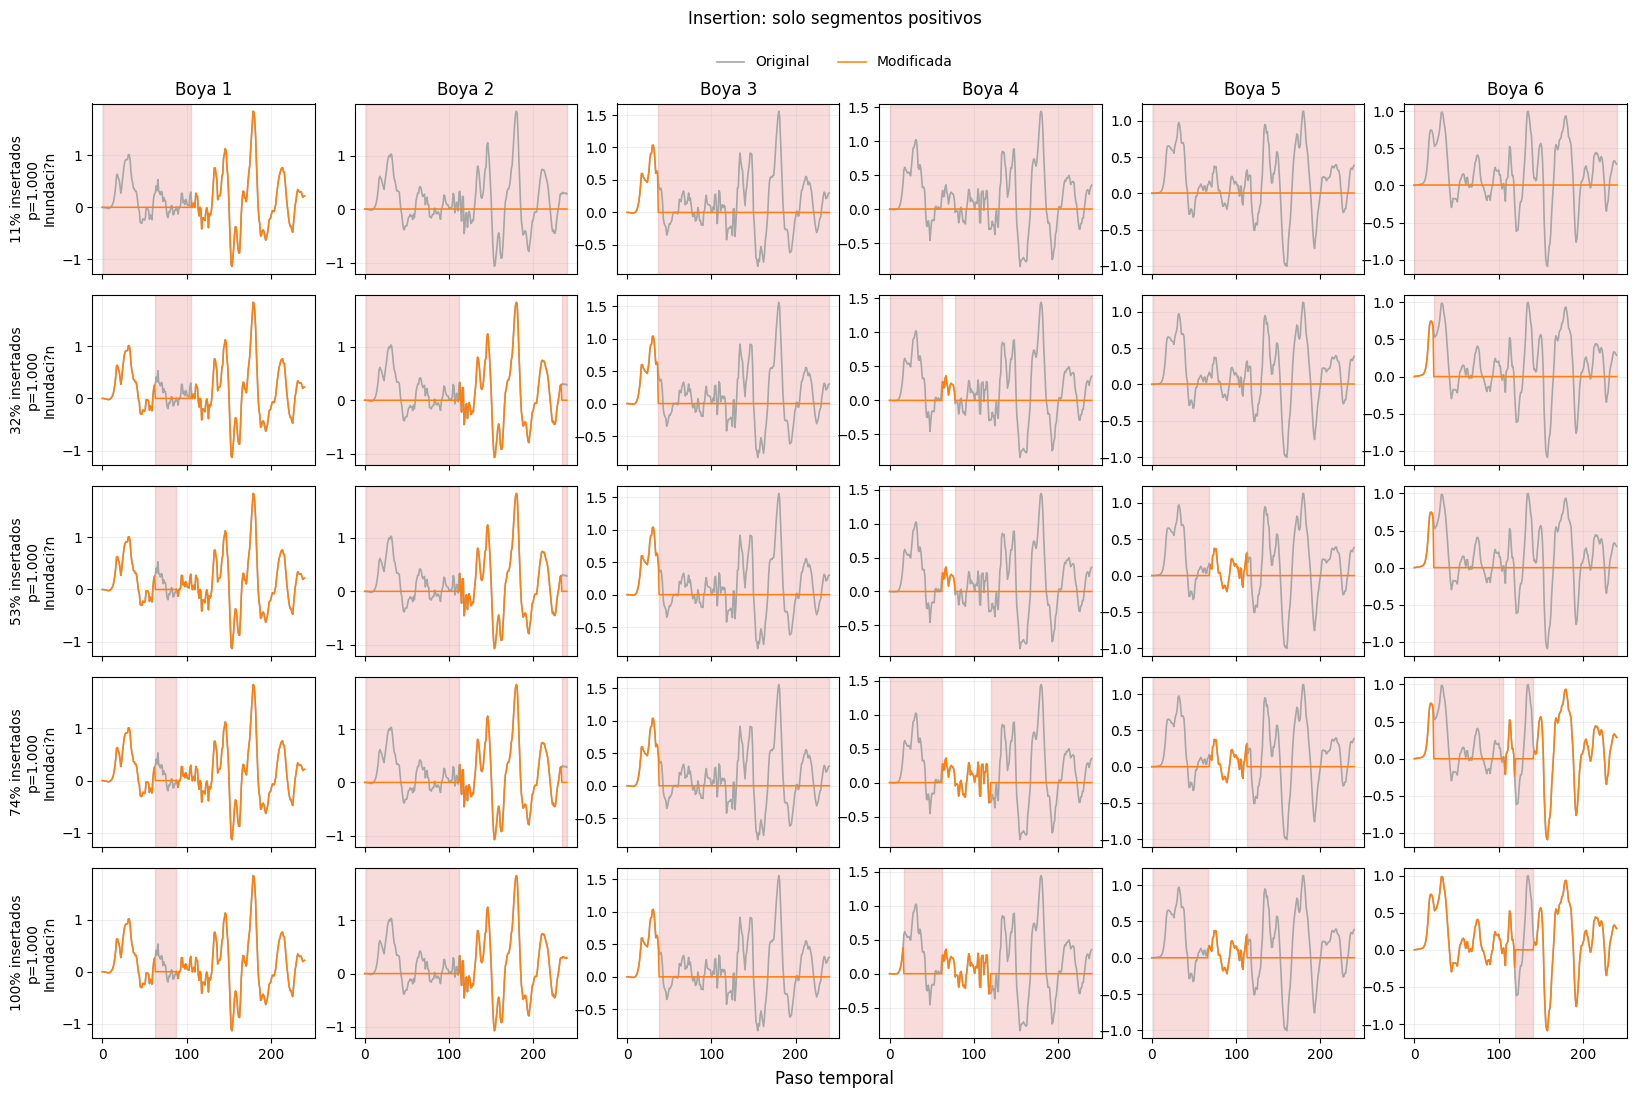

,fracci?n positivos,probabilidad,categor?a
0,0.105263,1.0,Inundaci?n
1,0.315789,1.0,Inundaci?n
2,0.526316,1.0,Inundaci?n
3,0.736842,1.0,Inundaci?n
4,1.000000,1.0,Inundaci?n


In [11]:
insert_positive_changes = plot_changed_zones('insertion')
insert_positive_changes

### Lectura

Esta versi?n pregunta algo m?s espec?fico: si se eliminan o insertan solo las regiones que apoyan la clase predicha, ?la probabilidad cambia en la direcci?n esperada? Si no hay segmentos positivos, el AUC queda como `NaN` porque no existe nada que eliminar o insertar bajo este criterio.